# **PERCOBAAN 4**

**Preprocessing:** Resize + Grayscale → Histogram Equalization + Median Filter → Sobel + Thresholding → **Morphological Opening + Morphological Closing**

---

## **GOOGLE COLABORATORY**

### **MENGHUBUNGKAN / MEMASANGKAN DENGAN GOOGLE DRIVE**

In [231]:
# from google.colab import drive
# drive.mount('/content/drive')

*Cell code* di atas menyediakan blok kode untuk menghubungkan notebook dengan **Google Drive** menggunakan fungsi `drive.mount()` dari modul `google.colab`. Seluruh baris dikomentar (`#`) sehingga tidak akan dieksekusi saat notebook dijalankan di lingkungan lokal atau **Visual Studio Code**. Blok ini cukup diaktifkan kembali dengan menghapus tanda `#` apabila notebook akan digunakan kembali di lingkungan **Google Colaboratory**.

### **PATH DATASET (GOOGLE COLABORATORY)**

In [232]:
# trial_path = "/content/drive/MyDrive/SEMESTER 4/MATA KULIAH/PENGOLAHAN CITRA DIGITAL   [W22B43]/PRAKTIKUM/PROYEK"
# dataset_path = "/content/drive/MyDrive/SEMESTER 4/MATA KULIAH/PENGOLAHAN CITRA DIGITAL   [W22B43]/PRAKTIKUM/PROYEK/dataset"
# healthy_path = dataset_path + "/healthy"
# diseased_path = dataset_path + "/diseased"

*Cell code* di atas berisi pendefinisian variabel jalur (*path*) dataset yang mengarah pada direktori di **Google Drive** milik pengguna. Variabel `trial_path`, `dataset_path`, `healthy_path`, dan `diseased_path` digunakan untuk menunjukkan lokasi folder proyek dan subfolder kelas citra. Seluruh baris dikomentar sehingga tidak aktif saat dijalankan secara lokal, dan dapat diaktifkan kembali ketika notebook dipindahkan ke **Google Colaboratory**.

### **MENJALANKAN PERCOBAAN-PERCOBAAN SEBELUMNYA**

In [233]:
# percobaan1_path = trial_path + "/Percobaan1.ipynb"
# %run "{percobaan1_path}"

In [234]:
# percobaan2_path = trial_path + "/Percobaan2.ipynb"
# %run "{percobaan2_path}"

In [235]:
# percobaan3_path = trial_path + "/Percobaan3.ipynb"
# %run "{percobaan3_path}"

*Cell code* pada ketiga sel di atas berisi perintah `%run` yang berfungsi untuk menjalankan seluruh isi notebook Percobaan 1, 2, dan 3 secara berurutan agar seluruh variabel hasil prapemrosesan dari ketiga percobaan sebelumnya (`dataPreprocessed` hingga `dataPreprocessed5`) tersedia di dalam sesi ini. Pendekatan ini merupakan cara kerja khusus di **Google Colaboratory**, sehingga seluruh barisnya dikomentar dan tidak dieksekusi saat notebook dijalankan secara lokal.

---

## **LOKAL / VISUAL STUDIO CODE**

### **MENGIMPOR LIBRARY**

In [236]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import entropy
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)

*Cell code* di atas digunakan untuk mengimpor seluruh *library* yang dibutuhkan selama proses pengolahan citra, ekstraksi fitur, hingga klasifikasi. **os** dan **cv2 (OpenCV)** digunakan untuk manajemen direktori serta operasi dasar pengolahan citra seperti pembacaan gambar dan konversi ruang warna. **NumPy** menangani operasi matriks piksel, **Pandas** menyimpan data fitur dalam bentuk *DataFrame*, sementara **Seaborn** dan **Matplotlib** berfungsi untuk keperluan visualisasi. **scipy.stats.entropy** dipakai untuk menghitung nilai entropi pada fitur GLCM. Dari **scikit-image**, fungsi `graycomatrix` dan `graycoprops` digunakan untuk mengekstraksi matriks ko-okurensi dan fitur-fitur teksturnya. Adapun dari **scikit-learn**, tersedia fungsi-fungsi untuk pembagian data, normalisasi, tiga model klasifikasi (*Random Forest*, *SVM*, *KNN*), serta metrik evaluasi model.

### **PATH DATASET (LOKAL)**

In [237]:
current_path = os.getcwd()
if os.path.exists(os.path.join(current_path, "dataset")):
    PROJECT_ROOT = current_path
elif os.path.exists(os.path.join(os.path.dirname(current_path), "dataset")):
    PROJECT_ROOT = os.path.dirname(current_path)
else:
    raise FileNotFoundError("Folder dataset tidak ditemukan. Pastikan folder 'dataset' ada di dalam project.")
DATASET_DIR = os.path.join(PROJECT_ROOT, "dataset")
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

healthy_path  = os.path.join(DATASET_DIR, "healthy")
diseased_path = os.path.join(DATASET_DIR, "diseased")

print("Folder dataset ditemukan di:", DATASET_DIR)
print("Folder daun sehat:", healthy_path)
print("Folder daun sakit:", diseased_path)

Folder dataset ditemukan di: d:\Proyek-Klasifikasi-Daun-Sehat-dan-Berpenyakit\dataset
Folder daun sehat: d:\Proyek-Klasifikasi-Daun-Sehat-dan-Berpenyakit\dataset\healthy
Folder daun sakit: d:\Proyek-Klasifikasi-Daun-Sehat-dan-Berpenyakit\dataset\diseased


*Cell code* di atas digunakan untuk mendeteksi secara otomatis lokasi folder `dataset` pada sistem berkas lokal. Algoritma ini pertama-tama memeriksa apakah folder `dataset` berada di direktori kerja saat ini menggunakan `os.getcwd()`. Jika tidak ditemukan, pencarian dilanjutkan ke direktori induk menggunakan `os.path.dirname()`. Apabila keduanya tidak mengandung folder dataset, program akan melempar pesan kesalahan `FileNotFoundError` secara eksplisit. Variabel `PROJECT_ROOT` kemudian digunakan sebagai basis pembentukan `DATASET_DIR` yang mengarah tepat ke folder `dataset`, serta variabel `VALID_EXTENSIONS` sebagai filter format file citra yang diterima.

In [238]:
# dataset_path  = os.path.join("..", "dataset")
# healthy_path  = os.path.join(dataset_path, "healthy")
# diseased_path = os.path.join(dataset_path, "diseased")

### **MENGECEK DATASET**

In [239]:
if not os.path.exists(healthy_path):
    print(f"Path healthy tidak ditemukan: {healthy_path}")
else:
    print(f"Healthy  : {len(os.listdir(healthy_path))} citra")

if not os.path.exists(diseased_path):
    print(f"Path diseased tidak ditemukan: {diseased_path}")
else:
    print(f"Diseased : {len(os.listdir(diseased_path))} citra")

Healthy  : 80 citra
Diseased : 80 citra


*Cell code* di atas digunakan untuk memvalidasi keberadaan subfolder `healthy` dan `diseased` di dalam direktori dataset menggunakan fungsi `os.path.exists()`. Apabila salah satu subfolder tidak ditemukan, program mencetak pesan notifikasi beserta jalur yang gagal dideteksi. Jika subfolder berhasil ditemukan, program menghitung dan mencetak jumlah file di dalamnya menggunakan `os.listdir()` sebagai konfirmasi awal bahwa dataset tersedia dan siap dimuat.

### **MEMUAT DATA**

In [240]:
def load_dataset(dataset_path):
    images = []
    labels = []
    file_names = []

    class_names = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
    class_counter = {class_name: 0 for class_name in class_names}

    for class_name in class_names:
        sub_folder_path = os.path.join(dataset_path, class_name)

        for filename in os.listdir(sub_folder_path):
            if class_counter[class_name] >= 100:
                break

            if not filename.lower().endswith(VALID_EXTENSIONS):
                continue

            img_path = os.path.join(sub_folder_path, filename)

            try:
                img_array = np.fromfile(img_path, np.uint8)
                img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
            except Exception:
                img = None

            if img is not None:
                images.append(img)
                labels.append(class_name)
                file_names.append(filename)
                class_counter[class_name] += 1
            else:
                print(f"Gagal membaca gambar: {img_path}")

    return np.array(images, dtype=object), np.array(labels), np.array(file_names), class_names, class_counter

*Cell code* di atas mendefinisikan fungsi `load_dataset(dataset_path)` yang bertugas memuat seluruh data citra dari folder dataset secara otomatis. Fungsi ini mengidentifikasi nama kelas berdasarkan subfolder yang ada, lalu membatasi pemuatan hingga maksimal **100 gambar per kelas** untuk menjaga keseimbangan data. Proses pembacaan gambar menggunakan kombinasi `np.fromfile()` dan `cv2.imdecode()` agar kompatibel dengan nama file yang mengandung karakter non-ASCII (seperti aksara Jepang atau Arab). Setiap gambar yang berhasil dimuat disimpan ke dalam *list* `images` beserta label kelasnya di `labels` dan nama filenya di `file_names`. Fungsi ini mengembalikan lima nilai sekaligus: array gambar bertipe `object`, array label, array nama file, daftar nama kelas, dan *dictionary* penghitung per kelas.

In [241]:
print("Loading dataset...")
data, labels, file_name, class_names, class_counter = load_dataset(DATASET_DIR)

print("\n--- INFO DATASET ---")
print("Jumlah data loaded:", len(data))
print("Label unik:", np.unique(labels))

Loading dataset...

--- INFO DATASET ---
Jumlah data loaded: 160
Label unik: ['diseased' 'healthy']


*Cell code* di atas digunakan untuk memanggil fungsi `load_dataset()` dan menyimpan hasilnya ke dalam lima variabel: `data` (kumpulan citra), `labels` (label kelas tiap citra), `file_name` (nama file), `class_names` (daftar nama kelas), dan `class_counter` (jumlah citra per kelas). Setelah pemuatan selesai, informasi ringkas mengenai jumlah total data dan label unik yang tersedia dicetak sebagai konfirmasi bahwa dataset berhasil dimuat dengan benar.

In [242]:
# data      = []
# labels    = []
# file_name = []

# for sub_folder in os.listdir(dataset_path):
#     sub_folder_path  = os.path.join(dataset_path, sub_folder)
#     if not os.path.isdir(sub_folder_path):
#         continue
#     for filename in os.listdir(sub_folder_path):
#         img_path = os.path.join(sub_folder_path, filename)
#         img = cv2.imread(img_path)
#         if img is None:
#             continue
#         img = img.astype(np.uint8)
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#         data.append(img)
#         labels.append(sub_folder)
#         file_name.append(filename)

# data   = np.array(data, dtype=object)
# labels = np.array(labels)

# print(f"Total data  : {len(data)} gambar")
# print(f"Label unik  : {np.unique(labels)}")

In [243]:
# data = []
# labels = []
# file_name = []

# for sub_folder in os.listdir(dataset_path):
#     sub_folder_files = os.listdir(os.path.join(dataset_path, sub_folder))
#     for i, filename in enumerate(sub_folder_files):
#         img_path = os.path.join(dataset_path, sub_folder, filename)
#         img = cv2.imread(img_path)
#         img = img.astype(np.uint8)
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#         data.append(img)
#         labels.append(sub_folder)
#         file_name.append(filename)

# data = np.array(data)
# labels = np.array(labels)

# print("Total data:", len(data))
# print("Label unik:", np.unique(labels))

### **DIAGRAM JUMLAH DATA PER KELAS**

*Cell code* di bawah digunakan untuk memvisualisasikan distribusi jumlah citra per kelas dalam bentuk diagram batang menggunakan fungsi `sns.barplot()` dari *library* **Seaborn**. Sumbu-x merepresentasikan nama kelas (`healthy` dan `diseased`), sedangkan sumbu-y menampilkan jumlah gambar yang berhasil dimuat untuk masing-masing kelas. Visualisasi ini penting untuk memverifikasi apakah data sudah terdistribusi secara seimbang sebelum memasuki tahap prapemrosesan.

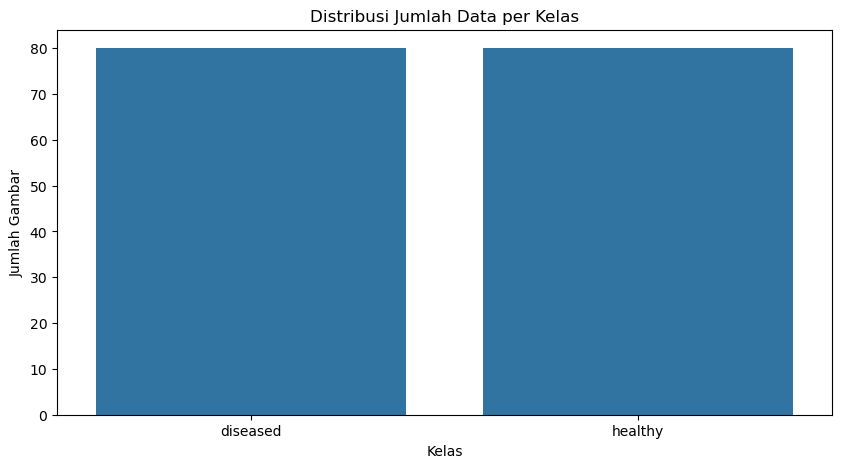

In [244]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counter.keys()), y=list(class_counter.values()))
plt.title('Distribusi Jumlah Data per Kelas')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.savefig('dataset_distribution.png')
plt.show()

## **PRAPEMROSESAN**

In [245]:
healthy_idxs  = [i for i, l in enumerate(labels) if l.lower() == 'healthy'][:80]
diseased_idxs = [i for i, l in enumerate(labels) if l.lower() == 'diseased'][:80]

print(f"Indeks healthy  : {len(healthy_idxs)} sampel")
print(f"Indeks diseased : {len(diseased_idxs)} sampel")

Indeks healthy  : 80 sampel
Indeks diseased : 80 sampel


*Cell code* di atas digunakan untuk membangun dua daftar indeks, yaitu `healthy_idxs` dan `diseased_idxs`, yang masing-masing berisi posisi indeks dari citra kelas *healthy* dan *diseased* pada array `data`. Proses penyaringan dilakukan menggunakan *list comprehension* dengan membandingkan nilai setiap elemen `labels` secara *case-insensitive* (`l.lower()`). Setiap daftar dibatasi hingga 80 indeks pertama menggunakan teknik *slicing* `[:80]` agar jumlah sampel visualisasi tetap konsisten pada grid 8×10.

In [246]:
def show_grid(images, idxs, title):
    fig, axs = plt.subplots(8, 10, figsize=(15, 12))
    fig.suptitle(title, fontsize=16)
    for k in range(len(idxs)):
        img = np.array(images[idxs[k]], dtype=np.uint8)
        axs[k // 10][k % 10].imshow(img, cmap='gray')
        axs[k // 10][k % 10].axis('off')
    for k in range(len(idxs), 80):
        axs[k // 10][k % 10].axis('off')
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

def show_images(images, idxs, title):
    fig, axs = plt.subplots(8, 10, figsize=(15, 12))
    fig.suptitle(title, fontsize=16)

    for k in range(len(idxs)):
        row = k // 10
        col = k % 10
        img = np.array(images[idxs[k]], dtype=np.uint8)
        axs[row][col].imshow(img, cmap='gray')
        axs[row][col].axis('off')

    for k in range(len(idxs), 80):
        row = k // 10
        col = k % 10
        axs[row][col].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

*Cell code* di atas mendefinisikan dua fungsi visualisasi, yaitu `show_grid()` dan `show_images()`, yang keduanya berfungsi menampilkan kumpulan citra dalam susunan grid 8×10 (80 gambar sekaligus). Fungsi `show_grid()` menggunakan `images[idxs[k]]` secara langsung, sementara `show_images()` memperlakukannya dengan cara yang sama namun dengan penamaan variabel serta perhitungan baris dan kolom yang lebih eksplisit (`row = k // 10`, `col = k % 10`). Keduanya mengonversi tipe data gambar ke `np.uint8` sebelum ditampilkan agar tidak terjadi kesalahan saat `plt.imshow()` menerima array bertipe `object`. Parameter `cmap='gray'` memastikan gambar ditampilkan dalam skala keabuan yang benar.

### **PERCOBAAN 1 (Resize + Grayscale)**

In [247]:
def percobaan1(img):
    img = np.array(img, dtype=np.uint8)

    if len(img.shape) == 3:  # kalau RGB/BGR
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img = cv2.resize(img, (128, 128))
    return img

*Cell code* di atas mendefinisikan fungsi `percobaan1(img)` yang mengimplementasikan dua tahap prapemrosesan awal secara berurutan. Pertama, citra dikonversi menjadi *grayscale* menggunakan `cv2.cvtColor()` dengan konstanta `cv2.COLOR_BGR2GRAY` hanya apabila citra masih dalam format tiga kanal warna (kondisi dicek melalui `len(img.shape) == 3`). Kedua, citra diubah ukurannya menjadi **128×128 piksel** menggunakan `cv2.resize()` untuk memastikan seluruh citra dalam dataset memiliki dimensi spasial yang seragam sebelum memasuki tahap ekstraksi fitur.

In [248]:
dataPreprocessed = [percobaan1(img) for img in data]

print(f"Preprocessing 1 selesai. Ukuran contoh: {dataPreprocessed[0].shape}")
# show_images(dataPreprocessed, healthy_idxs, "Healthy (Resize + Grayscale)")
# show_images(dataPreprocessed, diseased_idxs, "Diseased (Resize + Grayscale)")

Preprocessing 1 selesai. Ukuran contoh: (128, 128)


*Cell code* di atas digunakan untuk menerapkan fungsi `percobaan1()` pada seluruh elemen dalam `data` menggunakan *list comprehension*, lalu hasilnya disimpan ke variabel `dataPreprocessed`. Setelah proses selesai, ukuran citra pada indeks pertama dicetak sebagai verifikasi bahwa seluruh citra kini telah berukuran **128×128 piksel** sesuai target. Baris `show_images` dikomentari agar visualisasi grid tidak ditampilkan pada tahap ini dan hanya diaktifkan jika diperlukan.

### **PERCOBAAN 2 (Histogram Equalization + Median Filter)**

In [249]:
def ekualisasi(citra):
    tinggi, lebar = citra.shape

    # Histogram
    hist = np.zeros(256, dtype=np.int32)

    for i in range(tinggi):
        for j in range(lebar):
            nilai = int(citra[i, j])
            hist[nilai] += 1

    # CDF
    cdf = np.zeros(256, dtype=np.int32)
    cdf[0] = hist[0]

    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    # Normalisasi CDF ke rentang 0-255
    cdf_normal = np.round((cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())).astype(np.uint8)

    hasil = np.zeros((tinggi, lebar), dtype=np.uint8)

    for i in range(tinggi):
        for j in range(lebar):
            hasil[i, j] = cdf_normal[citra[i, j]]

    return hasil

*Cell code* di atas mendefinisikan fungsi `ekualisasi(citra)` yang mengimplementasikan teknik *Histogram Equalization* secara manual tanpa menggunakan fungsi bawaan *library*. Proses diawali dengan menghitung histogram distribusi frekuensi nilai piksel (0–255) melalui perulangan bersarang. Selanjutnya, dihitung *Cumulative Distribution Function* (CDF) secara iteratif dengan mengakumulasikan nilai histogram dari indeks 0 hingga 255. CDF kemudian dinormalisasi ke rentang 0–255 menggunakan rumus peregangan linear, lalu dibulatkan dan disimpan sebagai `cdf_normal`. Setiap piksel pada matriks citra dipetakan ulang menggunakan nilai `cdf_normal` sebagai tabel pencarian, sehingga distribusi intensitas menjadi lebih merata dan kontras citra meningkat.

In [250]:
dataPreprocessed2 = [ekualisasi(img) for img in dataPreprocessed]

# show_images(dataPreprocessed2, healthy_idxs, "Healthy + Histogram Equalization")
# show_images(dataPreprocessed2, diseased_idxs, "Diseased + Histogram Equalization")

*Cell code* di atas digunakan untuk menerapkan fungsi `ekualisasi()` pada seluruh elemen dalam `dataPreprocessed` (hasil *Resize* + *Grayscale*) melalui *list comprehension* dan hasilnya disimpan ke variabel `dataPreprocessed2`. Baris `show_images` dikomentari agar visualisasi grid tidak ditampilkan pada tahap ini.

In [251]:
def median_filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    area = padded[i:i + size, j:j + size]
                    canvas[i, j] = np.mean(area)
        case 'median':
            for i in range(height):
                for j in range(width):
                    area = padded[i:i + size, j:j + size]
                    canvas[i, j] = np.median(area)
        case 'modus':
            for i in range(height):
                for j in range(width):
                    area = padded[i:i + size, j:j + size]
                    values = area.flatten()
                    counts = np.bincount(values)
                    mode = np.argmax(counts)
                    canvas[i, j] = mode
    return canvas

*Cell code* di atas mendefinisikan fungsi `median_filter(img, size, mode)` yang mengimplementasikan tiga jenis *spatial filter* berbasis statistik secara manual menggunakan struktur `match mode`. Fungsi ini pertama-tama melakukan *padding* tepi citra menggunakan `np.pad()` dengan mode `'edge'` untuk menjaga dimensi keluaran tetap sama dengan masukan. Terdapat tiga pilihan mode yang tersedia: `'mean'` yang menghitung rata-rata nilai piksel pada jendela filter, `'median'` yang mengambil nilai tengah, serta `'modus'` yang mengambil nilai yang paling sering muncul menggunakan `np.bincount()`. Pada percobaan ini, mode `'median'` yang digunakan karena lebih efektif dalam menghilangkan *noise* impulsif (*salt-and-pepper noise*) tanpa mengaburkan tepi objek.

In [252]:
dataPreprocessed3 = [median_filter(img, 3, 'median') for img in dataPreprocessed2]

# show_images(dataPreprocessed3, healthy_idxs, "Healthy + Median Filter")
# show_images(dataPreprocessed3, diseased_idxs, "Diseased + Median Filter")

*Cell code* di atas digunakan untuk menerapkan fungsi `median_filter()` pada seluruh elemen dalam `dataPreprocessed2` (hasil *Histogram Equalization*) dengan ukuran kernel 3×3 dan mode `'median'`. Hasilnya disimpan ke variabel `dataPreprocessed3`. Baris `show_images` dikomentari agar visualisasi grid tidak ditampilkan pada tahap ini.

### **KERNEL**

In [253]:
kernel_smoothing = np.array(
    [
        [1 / 10, 1 / 10, 1 / 10],
        [1 / 10, 1 / 5,  1 / 10],
        [1 / 10, 1 / 10, 1 / 10]
    ],
    dtype=np.float32
)

kernel_sharpening = np.array(
    [
        [1 / 9, 1 / 9, 1 / 9],
        [1 / 9, 8 / 9, 1 / 9],
        [1 / 9, 1 / 9, 1 / 9]
    ],
    dtype=np.float32
)

kernel_sharpening_standar = np.array(
    [
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ],
    dtype=np.float32
)

kernel_sobel_x = np.array(
    [
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ],
    dtype=np.float32,
)

kernel_sobel_y = np.array(
    [
        [ 1,  2,  1],
        [ 0,  0,  0],
        [-1, -2, -1]
    ],
    dtype=np.float32,
)

kernel_prewitt_x = np.array(
    [
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ],
    dtype=np.float32,
)

kernel_prewitt_y = np.array(
    [
        [ 1,  1,  1],
        [ 0,  0,  0],
        [-1, -1, -1]
    ],
    dtype=np.float32,
)

kernel_roberts_x = np.array(
    [
        [1,  0],
        [0, -1]
    ],
    dtype=np.float32,
)

kernel_roberts_y = np.array(
    [
        [ 0, 1],
        [-1, 0]
    ],
    dtype=np.float32,
)

kernel_diamond = np.array(
    [
        [0,0,1,0,0],
        [0,1,1,1,0],
        [1,1,1,1,1],
        [0,1,1,1,0],
        [0,0,1,0,0]
    ],
    dtype=np.float32,
)

kernel_cross = np.array(
    [
        [0,1,0],
        [1,1,1],
        [0,1,0]
    ],
    dtype=np.float32
)

kernel_x = np.array(
    [
        [1,0,0,0,1],
        [0,1,0,1,0],
        [0,0,1,0,0],
        [0,1,0,1,0],
        [1,0,0,0,1]
    ],
    dtype=np.float32
)

kernel_fullsatu_3X3 = np.array(
    [
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ],
    dtype=np.uint8,
)

kernel_fullsatu_5X5 = np.array(
    [
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
    ],
    dtype=np.float32,
)

*Cell code* di atas digunakan untuk mendeklarasikan dan menginisialisasi seluruh *kernel* yang dibutuhkan dalam proses prapemrosesan dari Percobaan 1 hingga Percobaan 4. Terdapat beberapa kelompok *kernel* yang didefinisikan. `kernel_smoothing` dan `kernel_sharpening` adalah filter spasial berbobot untuk perataan dan penajaman citra. `kernel_sharpening_standar` adalah varian *sharpening* konvensional dengan nilai negatif pada tetangga langsung. `kernel_sobel_x` dan `kernel_sobel_y` adalah operator turunan pertama untuk mendeteksi gradien tepi secara horizontal dan vertikal. `kernel_prewitt_x/y` serta `kernel_roberts_x/y` adalah operator deteksi tepi alternatif dengan karakteristik bobot yang berbeda. `kernel_diamond`, `kernel_cross`, dan `kernel_x` adalah elemen penstruktur (*structuring element*) berbentuk geometris untuk operasi morfologi. Adapun `kernel_fullsatu_3X3` dan `kernel_fullsatu_5X5` adalah *kernel* penuh berukuran 3×3 dan 5×5 dengan seluruh elemen bernilai 1.

### **PERCOBAAN 3 (Sobel Edge Detection + Thresholding)**

In [254]:
def Konvolusi(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

*Cell code* di atas mendefinisikan fungsi `Konvolusi(img, kernel)` yang mengimplementasikan operasi konvolusi spasial secara manual. Fungsi ini diawali dengan menghitung ukuran *padding* berdasarkan setengah ukuran *kernel* (`pad_size = size // 2`), lalu menambahkan bingkai nol di sekeliling matriks citra menggunakan `np.pad()` dengan mode `'constant'`. Inti dari fungsi ini adalah empat perulangan bersarang yang menggeser jendela *kernel* di setiap koordinat piksel, lalu menghitung jumlah perkalian elemen matriks (*dot product*) menggunakan `np.sum(region * kernel)`. Hasilnya disimpan dalam *canvas* bertipe `float32` untuk menjaga presisi numerik sebelum nilai dikembalikan.

In [255]:
def edge(img, kernelx, kernely):
    gx = Konvolusi(img, kernelx)
    gy = Konvolusi(img, kernely)
    canvas = np. zeros_like(img, dtype=np. float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max (canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

*Cell code* di atas mendefinisikan fungsi `edge(img, kernelx, kernely)` yang berfungsi untuk mendeteksi tepi objek pada citra menggunakan pendekatan magnitudo gradien. Fungsi ini memanggil fungsi `Konvolusi()` dua kali: pertama untuk menghitung gradien horizontal `gx` menggunakan `kernelx`, dan kedua untuk menghitung gradien vertikal `gy` menggunakan `kernely`. Magnitudo gradien dihitung menggunakan rumus $G = |G_x| + |G_y|$, lalu dinormalisasi ke rentang 0–255 dengan cara membaginya terhadap nilai maksimum dan mengalikannya dengan 255. Nilai akhir dipotong (*clipping*) ke rentang `[0, 255]` menggunakan `np.clip()` dan dikembalikan dalam tipe data `uint8`.

In [256]:
dataPreprocessed4 = [edge(img, kernel_sobel_x, kernel_sobel_y) for img in dataPreprocessed3]

# show_images(dataPreprocessed4, healthy_idxs, "Healthy + Sobel Edge Detection")
# show_images(dataPreprocessed4, diseased_idxs, "Diseased + Sobel Edge Detection")

*Cell code* di atas digunakan untuk menerapkan deteksi tepi Sobel pada seluruh elemen dalam `dataPreprocessed3` (hasil *Median Filter*) melalui *list comprehension* menggunakan `kernel_sobel_x` dan `kernel_sobel_y` sebagai operator gradien. Hasilnya disimpan ke variabel `dataPreprocessed4`. Baris `show_images` dikomentari agar visualisasi grid tidak ditampilkan pada tahap ini.

In [257]:
def threshold(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if(img[i,j] > batas):
                canvas[i,j] = 255
            elif(img[i,j] <= batas):
                canvas[i,j] = 0
    return canvas

*Cell code* di atas mendefinisikan fungsi `threshold(img, batas)` yang mengimplementasikan teknik *binary thresholding* secara manual. Fungsi ini menelusuri setiap koordinat piksel melalui perulangan bersarang dan menerapkan aturan biner: piksel dengan nilai intensitas di atas `batas` dikonversi menjadi 255 (putih), sedangkan piksel dengan nilai sama dengan atau di bawah `batas` dikonversi menjadi 0 (hitam). Hasilnya adalah citra biner yang hanya memiliki dua nilai intensitas, sehingga tepi-tepi daun yang sudah dideteksi oleh Sobel menjadi lebih tegas dan terisolasi dari latar belakang.

In [258]:
dataPreprocessed5 = [threshold(img, 40) for img in dataPreprocessed4]

# show_images(dataPreprocessed5, healthy_idxs, "Healthy + Thresholding")
# show_images(dataPreprocessed5, diseased_idxs, "Diseased + Thresholding")

*Cell code* di atas digunakan untuk menerapkan *thresholding* pada seluruh elemen dalam `dataPreprocessed4` (hasil deteksi tepi Sobel) menggunakan nilai ambang batas sebesar **40**. Nilai 40 dipilih karena cukup rendah untuk menangkap mayoritas garis tepi daun tanpa terlalu banyak menyertakan piksel *noise* latar belakang. Hasilnya disimpan ke variabel `dataPreprocessed5`. Baris `show_images` dikomentari agar visualisasi grid tidak ditampilkan pada tahap ini.

### **MENDEFINISIKAN FUNGSI PRAPEMROSESAN PERCOBAAN 4**

In [259]:
def dilasi(citra, kernel):
    tinggi = citra.shape[0]
    lebar = citra.shape[1]
    tinggi_kernel = kernel.shape[0]
    lebar_kernel = kernel.shape[1]
    kanvas = np.zeros((tinggi, lebar), dtype=np.uint8)
    pusat_baris = tinggi_kernel // 2
    pusat_kolom = lebar_kernel // 2
    for baris in range(tinggi):
        for kolom in range(lebar):
            if citra[baris, kolom] == 255:
                for k_baris in range(tinggi_kernel):
                    for k_kolom in range(lebar_kernel):
                        if kernel[k_baris, k_kolom] == 1:
                            target_baris = baris + k_baris - pusat_baris
                            target_kolom = kolom + k_kolom - pusat_kolom
                            if (
                                0 <= target_baris < tinggi
                                and 0 <= target_kolom < lebar
                            ):
                                kanvas[target_baris, target_kolom] = 255
    return kanvas

*Cell code* di atas mendefinisikan fungsi `dilasi(citra, kernel)` yang mengimplementasikan operasi morfologi dilasi secara manual. Algoritma ini menelusuri setiap piksel pada citra masukan; apabila nilai piksel adalah **255** (putih), maka setiap elemen *kernel* yang bernilai 1 akan menyalakan piksel yang bersesuaian di matriks `kanvas` output sesuai dengan offset relatif terhadap titik pusat *kernel* (`pusat_baris`, `pusat_kolom`). Pengecekan batas matriks dilakukan menggunakan kondisi `0 <= target_baris < tinggi` dan `0 <= target_kolom < lebar` agar proses tidak mengakses indeks di luar jangkauan. Secara visual, operasi ini memperluas atau mempertebal area putih pada citra biner.

In [260]:
def erosi(citra, kernel):
    tinggi = citra.shape[0]
    lebar = citra.shape[1]
    tinggi_kernel = kernel.shape[0]
    lebar_kernel = kernel.shape[1]
    kanvas = np.zeros((tinggi, lebar), dtype=np.uint8)
    pusat_baris = tinggi_kernel // 2
    pusat_kolom = lebar_kernel // 2
    for baris in range(tinggi):
        for kolom in range(lebar):
            if citra[baris, kolom] == 255:
                cocok = True
                for k_baris in range(tinggi_kernel):
                    for k_kolom in range(lebar_kernel):
                        if kernel[k_baris, k_kolom] == 1:
                            target_baris = baris + k_baris - pusat_baris
                            target_kolom = kolom + k_kolom - pusat_kolom
                            if 0 <= target_baris < tinggi and 0 <= target_kolom < lebar:
                                if citra[target_baris, target_kolom] == 0:
                                    cocok = False
                                    break
                            else:
                                cocok = False
                                break
                    if not cocok:
                        break
                if cocok:
                    kanvas[baris, kolom] = 255
    return kanvas

*Cell code* di atas mendefinisikan fungsi `erosi(citra, kernel)` yang mengimplementasikan operasi morfologi erosi secara manual. Berbeda dengan dilasi, fungsi ini bersifat selektif: piksel pada koordinat tertentu hanya dipertahankan bernilai **255** apabila seluruh tetangga yang tercakup dalam *kernel* (semua elemen bernilai 1) juga bernilai 255. Kondisi ini diperiksa melalui variabel *flag* `cocok` yang diset menjadi `False` begitu satu saja tetangga yang diperlukan bernilai 0 atau berada di luar batas matriks. Secara visual, operasi ini mengikis tepi terluar area putih dan menghilangkan komponen kecil yang tidak cukup 'besar' untuk memenuhi syarat *structuring element*.

In [261]:
def opening(citra, kernel):
    return dilasi(erosi(citra, kernel), kernel)

*Cell code* di atas mendefinisikan fungsi `opening(citra, kernel)` yang mengimplementasikan operasi morfologi *opening* sebagai komposisi dua fungsi dasar secara berurutan. Citra masukan terlebih dahulu diproses oleh fungsi `erosi()` untuk menghilangkan komponen-komponen kecil dan *noise* titik. Hasilnya kemudian diteruskan ke fungsi `dilasi()` untuk memulihkan ukuran objek yang tersisa agar tidak menyusut terlalu drastis. *Opening* = `erosi` terlebih dahulu, baru `dilasi`.

In [262]:
def closing(citra, kernel):
    return erosi(dilasi(citra, kernel), kernel)

*Cell code* di atas mendefinisikan fungsi `closing(citra, kernel)` yang mengimplementasikan operasi morfologi *closing* sebagai kebalikan urutan dari fungsi `opening()`. Citra masukan terlebih dahulu diproses oleh fungsi `dilasi()` untuk menjembatani celah-celah kecil dan menyambungkan komponen yang hampir terhubung. Hasilnya kemudian diteruskan ke fungsi `erosi()` untuk memulihkan ukuran objek agar tidak melebar berlebihan. *Closing* = `dilasi` terlebih dahulu, baru `erosi`.

### **MENERAPKAN OPENING**

*Cell code* di bawah digunakan untuk menerapkan operasi morfologi *opening* pada seluruh elemen dalam `dataPreprocessed5` (hasil *Thresholding*) menggunakan `kernel_cross` berukuran 3×3 sebagai elemen penstruktur. `kernel_cross` dipilih karena hanya memeriksa empat tetangga langsung (atas, bawah, kiri, kanan) sehingga bersifat lebih *gentle* dan tidak terlalu agresif dalam mengikis tepi tipis pada citra biner hasil Sobel. Hasil disimpan ke `dataPreprocessed6`, lalu divisualisasikan dalam susunan grid 8×10 secara terpisah untuk kelas *healthy* dan *diseased*.

Opening selesai. Jumlah citra: 160


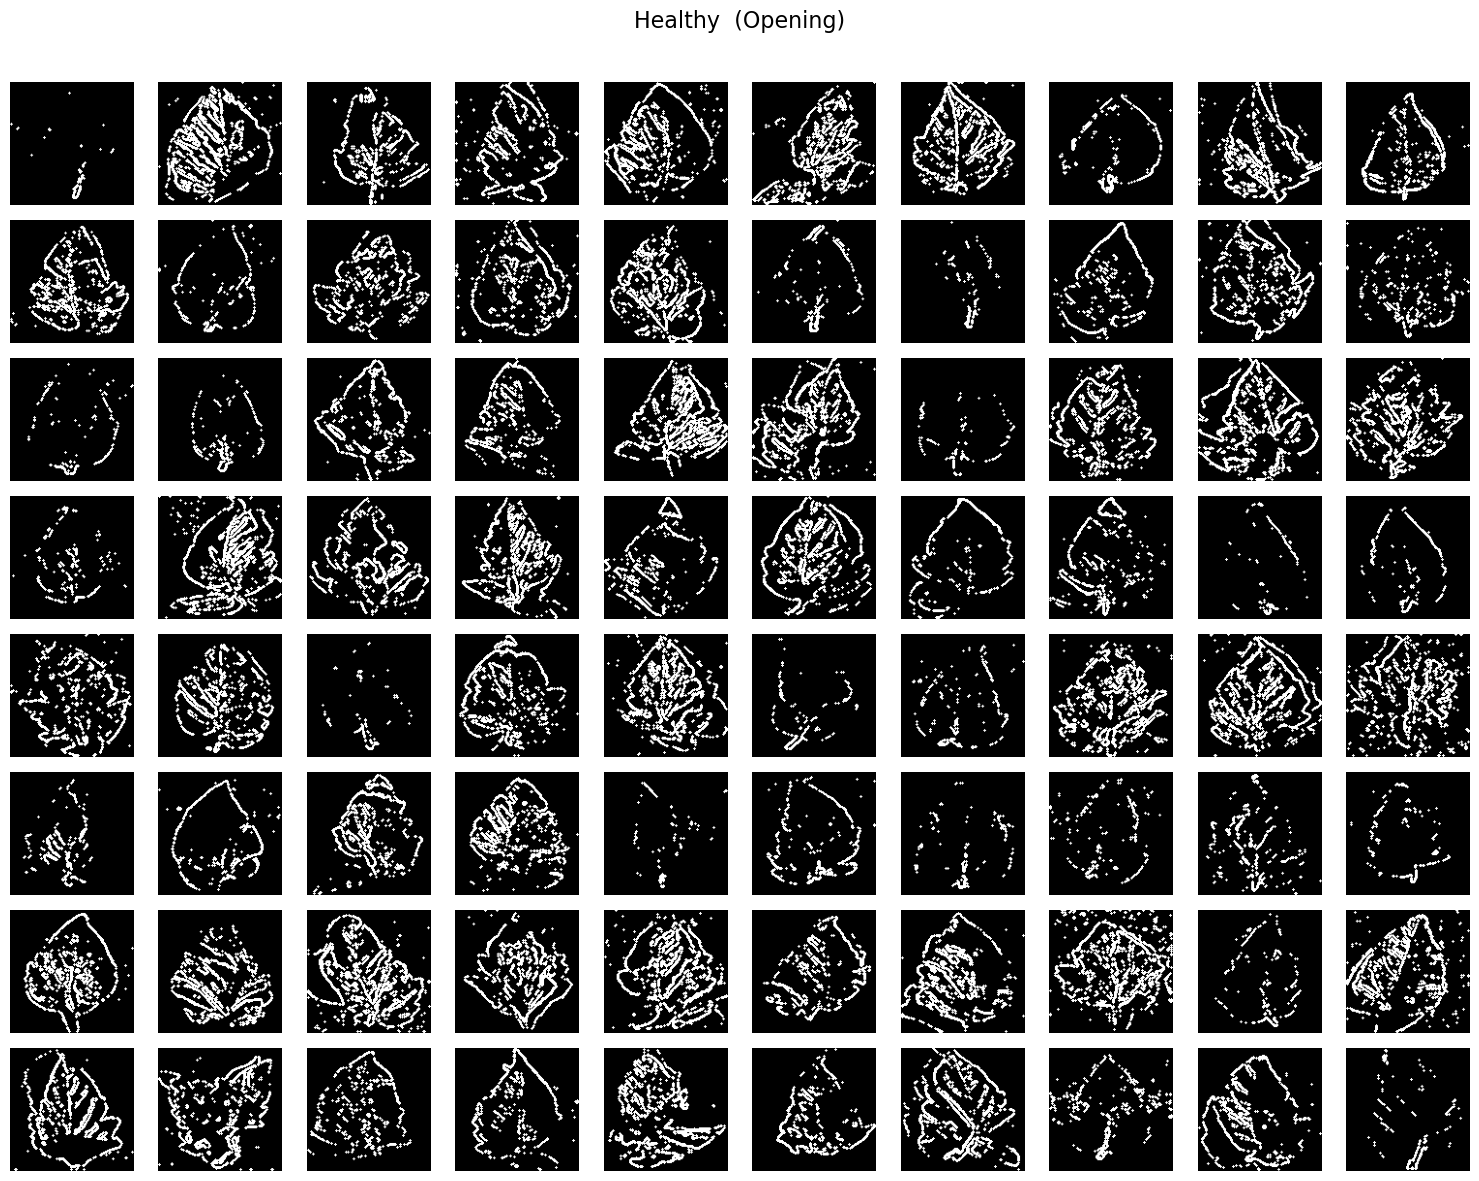

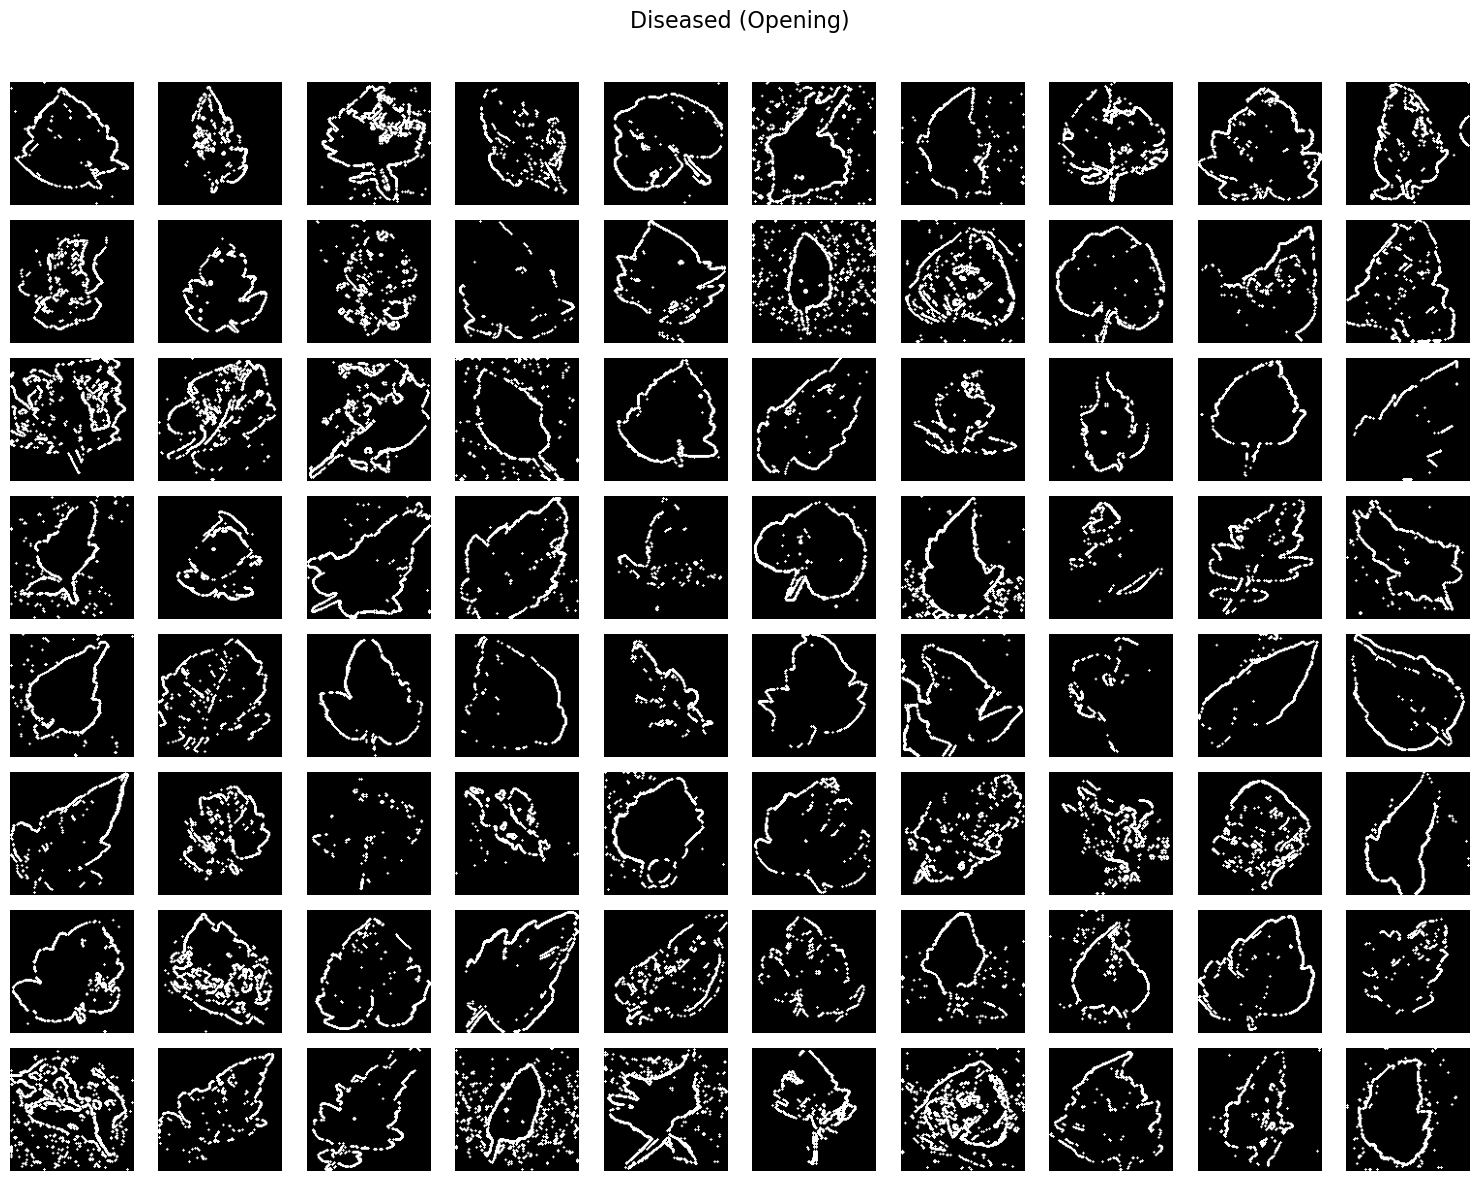

In [263]:
dataPreprocessed6 = [opening(img, kernel_cross) for img in dataPreprocessed5]

print(f'Opening selesai. Jumlah citra: {len(dataPreprocessed6)}')
show_images(dataPreprocessed6, healthy_idxs,  'Healthy  (Opening)')
show_images(dataPreprocessed6, diseased_idxs, 'Diseased (Opening)')

### **MENERAPKAN CLOSING**

*Cell code* di bawah digunakan untuk menerapkan operasi morfologi *closing* pada seluruh elemen dalam `dataPreprocessed6` (hasil *Opening*) menggunakan `kernel_cross` yang sama. *Closing* berfungsi menjembatani celah kecil yang tersisa pada garis tepi dan menutup lubang kecil di dalam objek agar struktur kontur lebih menyambung. Hasil disimpan ke `dataPreprocessed7` sebagai data prapemrosesan akhir yang akan digunakan pada tahap ekstraksi fitur GLCM, lalu divisualisasikan dalam susunan grid 8×10 untuk kedua kelas.

Closing selesai. Jumlah citra: 160


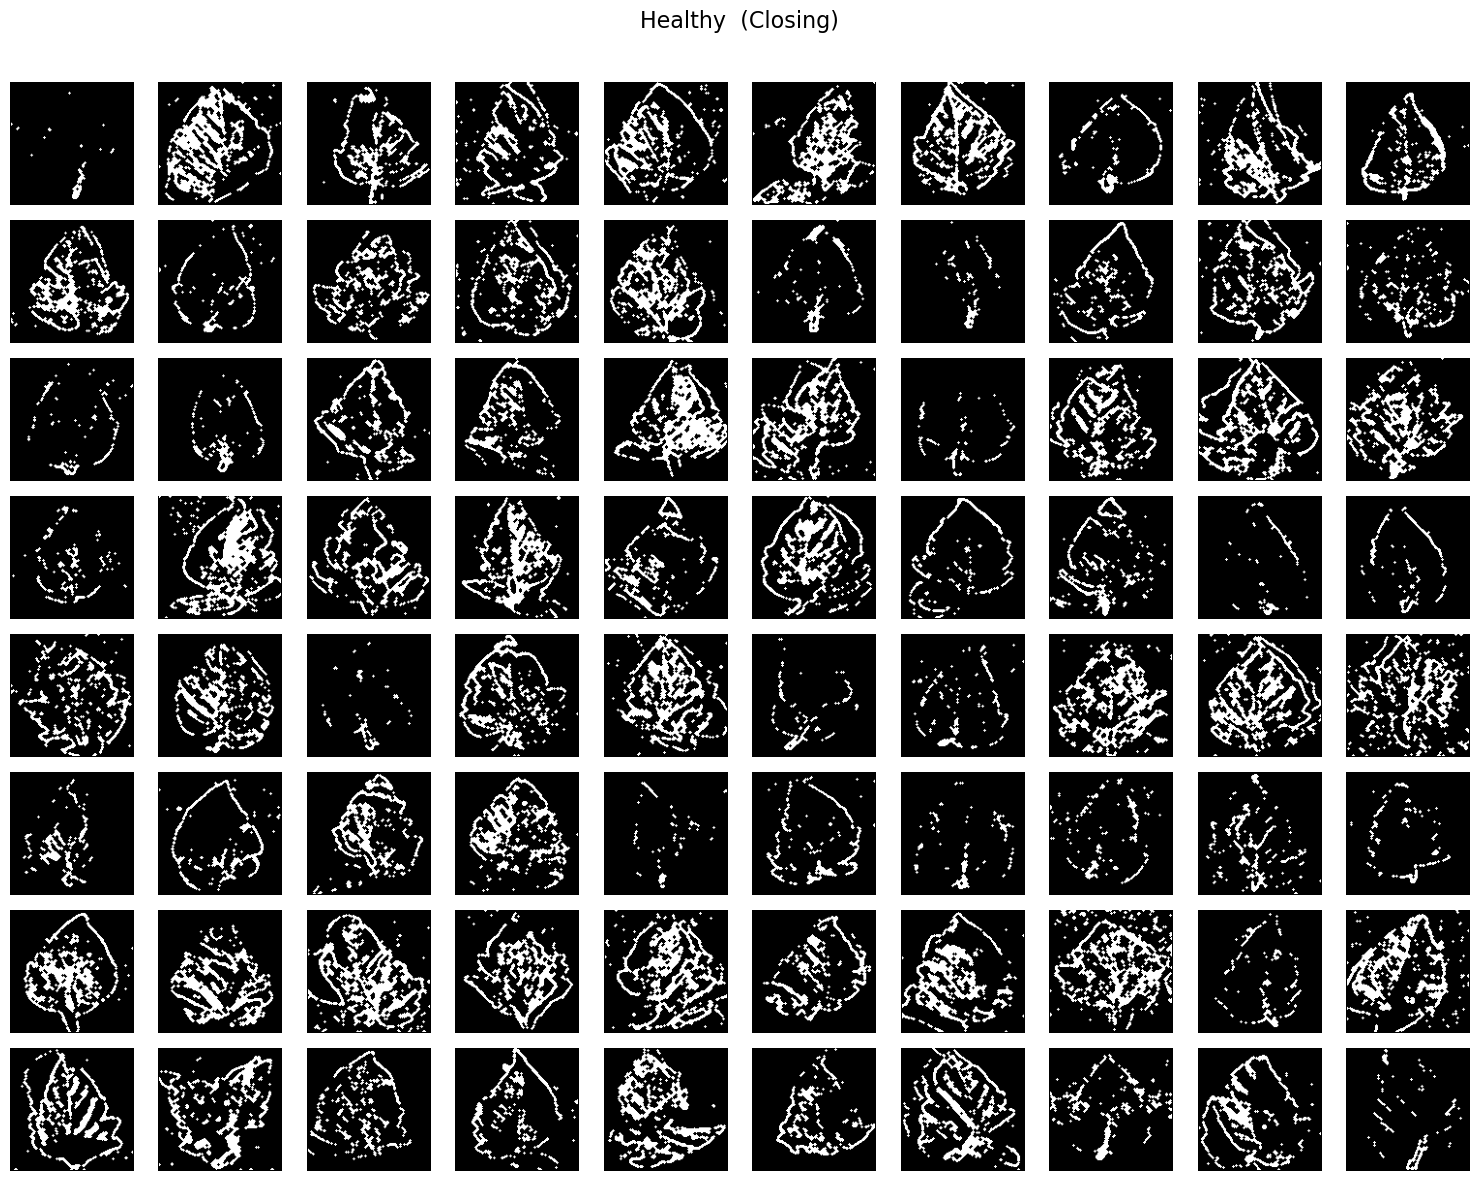

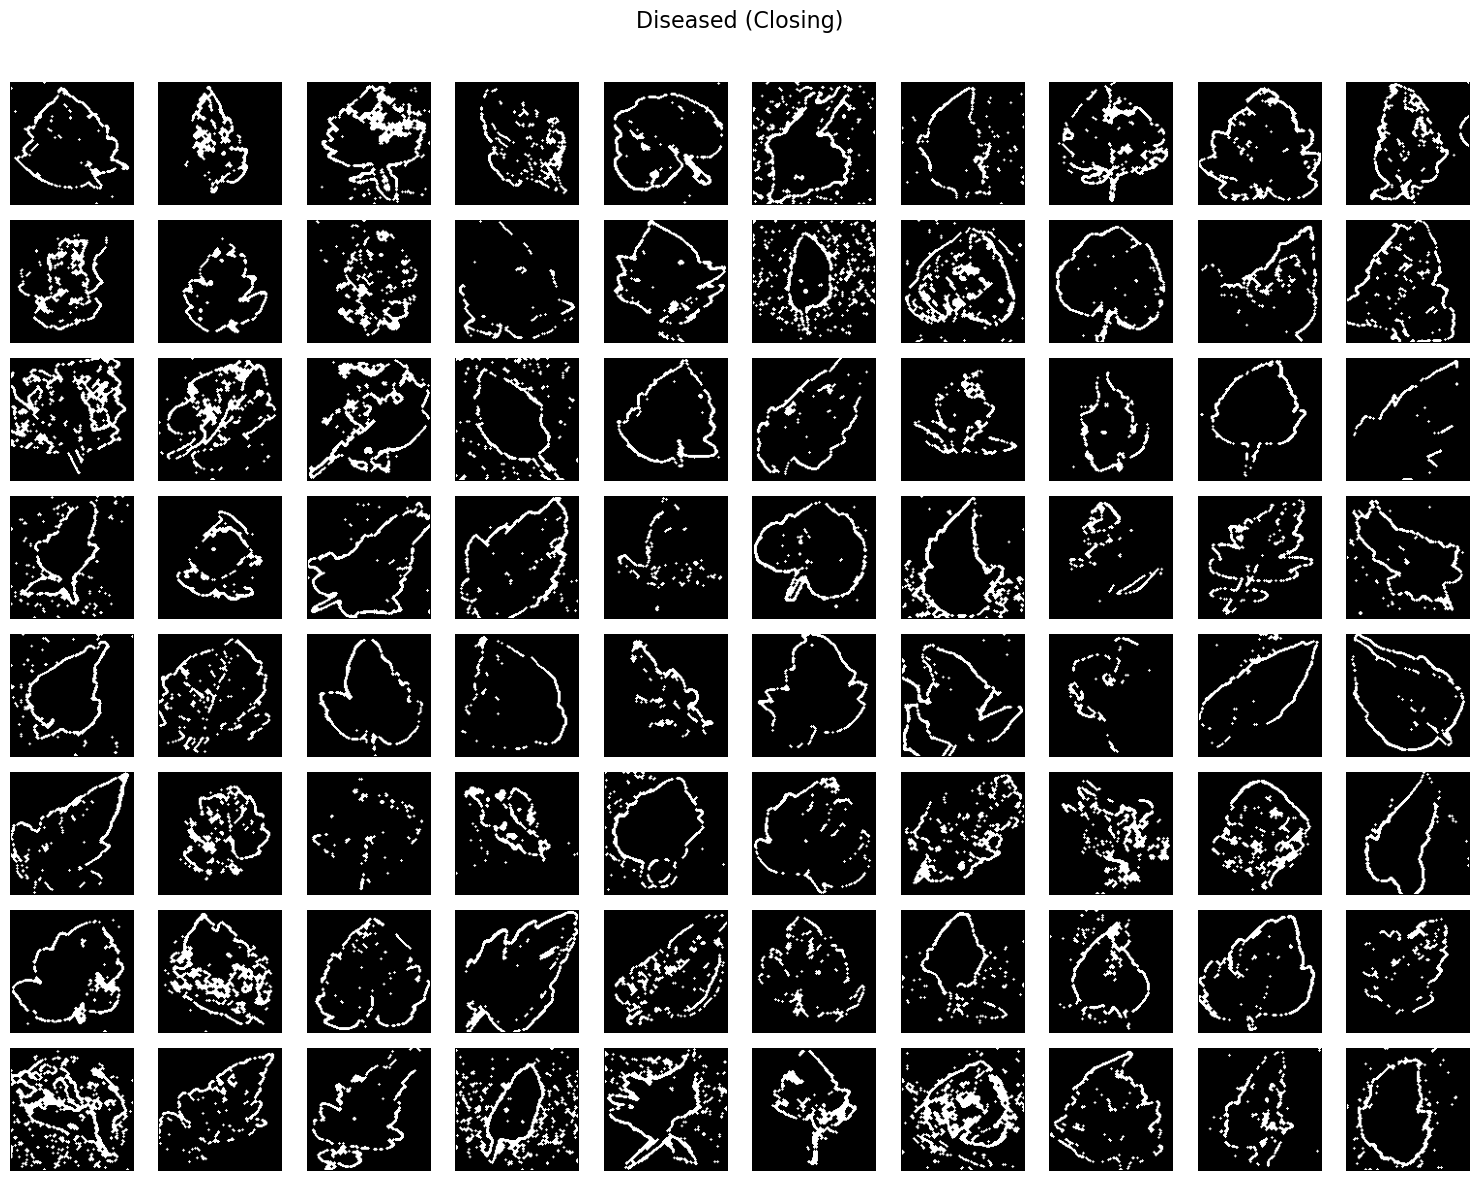

In [264]:
dataPreprocessed7 = [closing(img, kernel_cross) for img in dataPreprocessed6]

print(f'Closing selesai. Jumlah citra: {len(dataPreprocessed7)}')
show_images(dataPreprocessed7, healthy_idxs,  'Healthy  (Closing)')
show_images(dataPreprocessed7, diseased_idxs, 'Diseased (Closing)')

### **VISUALISASI PERBANDINGAN TAHAP PRAPEMROSESAN**

*Cell code* di bawah digunakan untuk menampilkan visualisasi *pipeline* prapemrosesan secara menyeluruh dari awal hingga akhir dalam satu baris gambar. Untuk setiap kelas (*Healthy* dan *Diseased*), diambil satu citra sampel (indeks pertama dari masing-masing kelas) lalu ditampilkan dalam delapan kolom yang merepresentasikan tahapan: citra asli, *Resize+Grayscale*, *Histogram Equalization*, *Median Filter*, deteksi tepi *Sobel*, *Thresholding*, *Opening*, dan *Closing*. Visualisasi ini berguna untuk memeriksa secara visual bagaimana citra berubah di setiap tahap prapemrosesan dari awal hingga siap diekstraksi fiturnya.

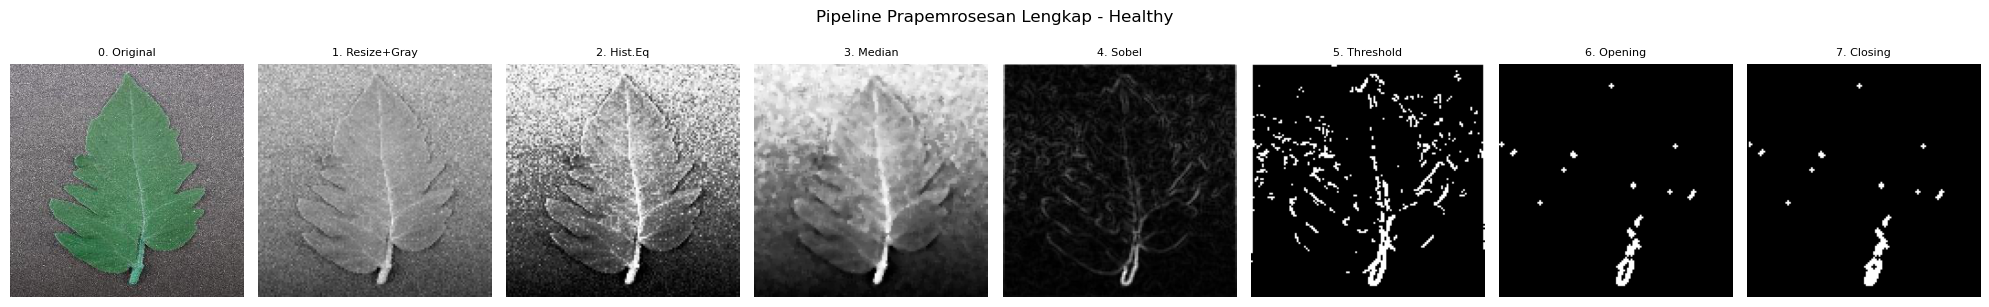

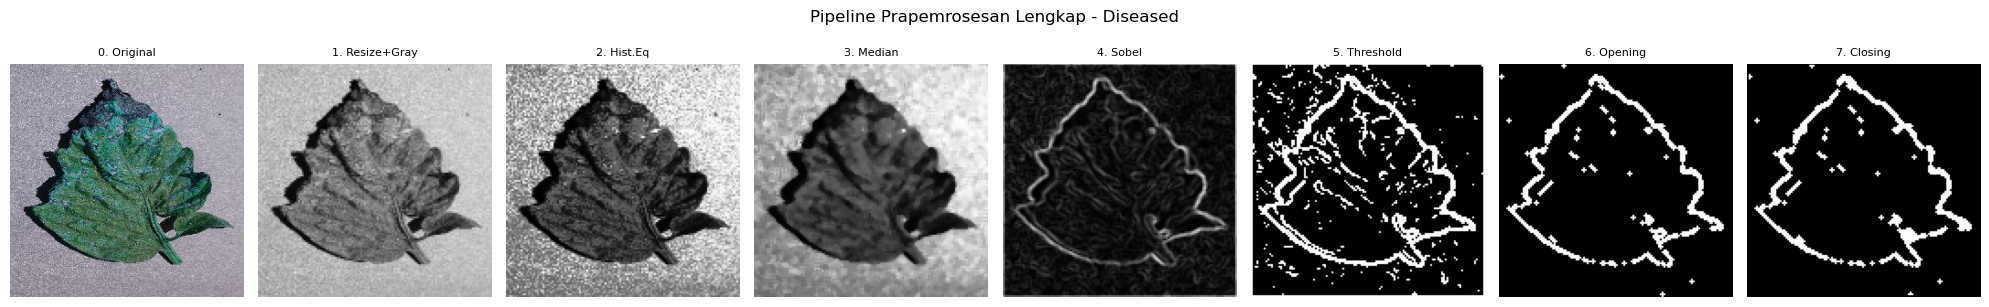

In [265]:
for idx, nama_kelas in [(healthy_idxs[0], 'Healthy'), (diseased_idxs[0], 'Diseased')]:
    tahap_imgs = [
        data[idx],
        dataPreprocessed[idx],
        dataPreprocessed2[idx],
        dataPreprocessed3[idx],
        dataPreprocessed4[idx],
        dataPreprocessed5[idx],
        dataPreprocessed6[idx],
        dataPreprocessed7[idx],
    ]
    tahap_labels = [
        '0. Original', '1. Resize+Gray', '2. Hist.Eq',
        '3. Median', '4. Sobel', '5. Threshold',
        '6. Opening', '7. Closing',
    ]
    fig, axs = plt.subplots(1, 8, figsize=(20, 3))
    fig.suptitle(f'Pipeline Prapemrosesan Lengkap - {nama_kelas}', fontsize=12, y=1.02)
    for k, (img, lbl) in enumerate(zip(tahap_imgs, tahap_labels)):
        img_show = np.array(img, dtype=np.uint8)
        axs[k].imshow(img_show, cmap='gray')
        axs[k].set_title(lbl, fontsize=8)
        axs[k].axis('off')
    plt.tight_layout()
    plt.show()

## **GRAY LEVEL CO-OCCURRENCE MATRIX (GLCM)**

In [266]:
print('Siap melakukan ekstraksi GLCM pada', len(dataPreprocessed7), 'citra.')

Siap melakukan ekstraksi GLCM pada 160 citra.


*Cell code* di atas digunakan untuk mencetak informasi awal sebelum proses ekstraksi GLCM dimulai, yaitu jumlah total citra yang akan diproses berdasarkan panjang `dataPreprocessed7`. Ini berfungsi sebagai konfirmasi bahwa data hasil prapemrosesan terakhir sudah tersedia dan siap dimasukkan ke dalam pipeline ekstraksi fitur.

### **MENDEFINISIKAN FUNGSI GLCM**

In [267]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError('Sudut tidak valid. Pilih: 0, 45, 90, atau 135.')
    matriks = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return matriks

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

print('Fungsi GLCM berhasil didefinisikan.')

Fungsi GLCM berhasil didefinisikan.


*Cell code* di atas mendefinisikan delapan fungsi yang menjadi fondasi ekstraksi fitur tekstur berbasis *Gray Level Co-occurrence Matrix* (GLCM). Fungsi `glcm(image, derajat)` memanggil `graycomatrix()` dari *library* **scikit-image** untuk menghasilkan matriks ko-okurensi pada salah satu dari empat sudut: **0°** (horizontal), **45°** (diagonal), **90°** (vertikal), atau **135°** (anti-diagonal), dengan jarak piksel sebesar 1, ukuran level abu-abu 256, serta mode `symmetric=True` dan `normed=True` agar matriks bersifat simetris dan ternormalisasi. Kemudian tersedia enam fungsi ekstraksi fitur yang masing-masing memanggil `graycoprops()`: `correlation()` mengukur korelasi linear antar piksel bertetangga, `dissimilarity()` mengukur seberapa berbeda nilai intensitasnya, `homogenity()` mengukur keseragaman distribusi, `contrast()` mengukur perbedaan kontras lokal, `ASM()` (*Angular Second Moment*) mengukur keseragaman tekstur, dan `energy()` merupakan akar kuadrat dari ASM. Fungsi `entropyGlcm()` menghitung entropi dari nilai-nilai matriks yang telah diratakan (*flatten*) menggunakan `scipy.stats.entropy`.

### **MENGHITUNG GLCM UNTUK SETIAP SUDUT**

In [268]:
Derajat0, Derajat45, Derajat90, Derajat135 = [], [], [], []

for i in range(len(dataPreprocessed7)):
    Derajat0.append(glcm(dataPreprocessed7[i], 0))
    Derajat45.append(glcm(dataPreprocessed7[i], 45))
    Derajat90.append(glcm(dataPreprocessed7[i], 90))
    Derajat135.append(glcm(dataPreprocessed7[i], 135))

print(f'GLCM dihitung untuk {len(dataPreprocessed7)} citra pada 4 sudut.')

GLCM dihitung untuk 160 citra pada 4 sudut.


*Cell code* di atas digunakan untuk menghitung matriks GLCM pada empat sudut berbeda untuk setiap citra dalam `dataPreprocessed7`. Empat *list* kosong (`Derajat0`, `Derajat45`, `Derajat90`, `Derajat135`) diinisialisasi terlebih dahulu, lalu diisi melalui perulangan dengan memanggil fungsi `glcm()` pada setiap citra untuk masing-masing sudut. Pendekatan multi-sudut ini penting karena tekstur daun dapat memiliki pola yang berbeda tergantung arah pengamatannya, sehingga penggunaan empat sudut sekaligus menghasilkan representasi tekstur yang lebih komprehensif.

### **MENGEKSTRAKSI SEMUA FITUR**

In [269]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed7)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

print('Ekstraksi fitur selesai.')

Ekstraksi fitur selesai.


*Cell code* di atas digunakan untuk mengekstraksi tujuh jenis fitur tekstur dari matriks GLCM pada setiap sudut untuk seluruh citra. Proses dimulai dengan inisialisasi 28 *list* kosong (7 fitur × 4 sudut). Melalui perulangan, setiap citra diproses untuk menghasilkan nilai *contrast*, *dissimilarity*, *homogeneity*, *entropy*, *ASM*, *energy*, dan *correlation* pada keempat sudut (0°, 45°, 90°, 135°) dengan memanggil fungsi-fungsi yang telah didefinisikan sebelumnya. Dengan jumlah citra 160 dan 28 fitur, hasil akhirnya adalah 160 baris × 28 kolom fitur yang merepresentasikan karakteristik tekstur setiap citra.

### **MENYIMPAN HASIL EKSTRAKSI KE CSV**

In [270]:
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan4.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan4.csv')
print(f'Data tersimpan: {hasilEkstrak.shape[0]} baris, {hasilEkstrak.shape[1]} kolom')
hasilEkstrak
# .head()

Data tersimpan: 160 baris, 30 kolom


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,00f16858-f392-4d9e-ad9f-efab8049a13f___JR_Sept...,diseased,2672.041093,2910.784922,2856.043922,3580.023560,0.958908,0.955237,0.956078,0.944945,...,0.812305,0.801225,0.902715,0.900272,0.901280,0.895112,0.717969,0.694963,0.698547,0.624830
1,01f54ad9-9c03-4ffd-86f4-829fc2939120___Matt.S_...,diseased,2688.041339,2967.226734,2312.035556,2959.163618,0.958662,0.954369,0.964444,0.954493,...,0.802013,0.791707,0.892567,0.889716,0.895552,0.889779,0.747466,0.723200,0.782791,0.723952
2,02ab6821-757a-401b-ac04-919fdceee1f0___Matt.S_...,diseased,4416.067913,5434.540269,4704.072343,5345.845992,0.932088,0.916425,0.927659,0.917789,...,0.648627,0.638511,0.807734,0.798357,0.805374,0.799069,0.761091,0.707812,0.745509,0.712580
3,0a146952-538a-41e5-a422-b5d50e91771e___Matt.S_...,diseased,3624.055733,3475.203050,3416.052534,4442.776986,0.944268,0.946557,0.947466,0.931677,...,0.789767,0.774745,0.887082,0.887588,0.888688,0.880196,0.652662,0.669280,0.672598,0.577200
4,0a25f893-1b5f-4845-baa1-f68ac03d96ac___Matt.S_...,diseased,2968.045645,3467.139934,3144.048351,3967.053134,0.954356,0.946681,0.951649,0.938993,...,0.774833,0.762307,0.881638,0.876993,0.880246,0.873102,0.745220,0.704445,0.730111,0.661830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,1ddf5950-e27f-4928-8f4e-33242953e306___RS_HL 0...,healthy,3464.053273,3862.232624,3432.052781,4104.126108,0.946728,0.940605,0.947220,0.936885,...,0.772234,0.761850,0.878518,0.874708,0.878768,0.872840,0.700331,0.668210,0.703100,0.647430
156,1dfb5aeb-8d00-4672-9755-5da982758453___RS_HL 9...,healthy,6032.092766,6256.978114,5832.089690,7506.761114,0.907236,0.903777,0.910311,0.884558,...,0.601706,0.579359,0.774075,0.771045,0.775697,0.761157,0.707038,0.697906,0.716752,0.637565
157,1dffd343-4634-4b33-95f4-eecc755aec8f___GH_HL L...,healthy,3552.054626,3805.790812,3424.052657,3813.853928,0.945375,0.941473,0.947343,0.941349,...,0.786420,0.779932,0.885812,0.883200,0.886803,0.883138,0.666294,0.644973,0.678320,0.644221
158,1e1aa3d8-d12f-47e1-b316-b8656ab3f2b6___RS_HL 0...,healthy,4584.070497,4466.966334,4432.068159,5926.390353,0.929504,0.931305,0.931842,0.908861,...,0.690034,0.669102,0.829470,0.829433,0.830683,0.817987,0.713953,0.723071,0.723438,0.632594


*Cell code* di atas digunakan untuk merangkum seluruh hasil ekstraksi fitur ke dalam sebuah *dictionary* `dataTable` yang memuat kolom identitas (`Filename`, `Label`) beserta 28 kolom fitur GLCM. *Dictionary* ini kemudian dikonversi menjadi *DataFrame* menggunakan **Pandas** dan disimpan ke file CSV bernama `hasil_ekstraksi_percobaan4.csv` menggunakan metode `to_csv()`. File tersebut dibaca kembali ke variabel `hasilEkstrak` untuk memastikan data tersimpan dengan benar, lalu informasi dimensi data (jumlah baris dan kolom) dicetak sebagai konfirmasi. Seluruh isi *DataFrame* ditampilkan untuk memverifikasi bahwa semua fitur sudah terkumpul dengan struktur yang tepat.

## **SELEKSI FITUR**

### **MENGGUNAKAN KORELASI**

*Cell code* di bawah digunakan untuk melakukan seleksi fitur berbasis korelasi guna menghilangkan fitur-fitur yang redundan sebelum data dimasukkan ke dalam model klasifikasi. Matriks korelasi dihitung dari `hasilEkstrak` menggunakan metode `.corr()` setelah kolom non-fitur (`Label`, `Filename`) dibuang. Selanjutnya, algoritma iteratif memeriksa setiap pasangan fitur; jika nilai korelasi di antara keduanya melebihi ambang batas `ambang_korelasi = 0.95`, maka fitur dengan indeks lebih tinggi ditandai untuk dieliminasi. Fitur-fitur yang lolos seleksi disimpan ke variabel `x_new`, sementara distribusi korelasi antar fitur terpilih divisualisasikan dalam bentuk *heatmap* menggunakan **Seaborn** dengan anotasi nilai korelasi pada setiap sel.

Fitur sebelum seleksi : 28
Fitur setelah seleksi : 6
Fitur terpilih        : ['Contrast0', 'Homogeneity0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


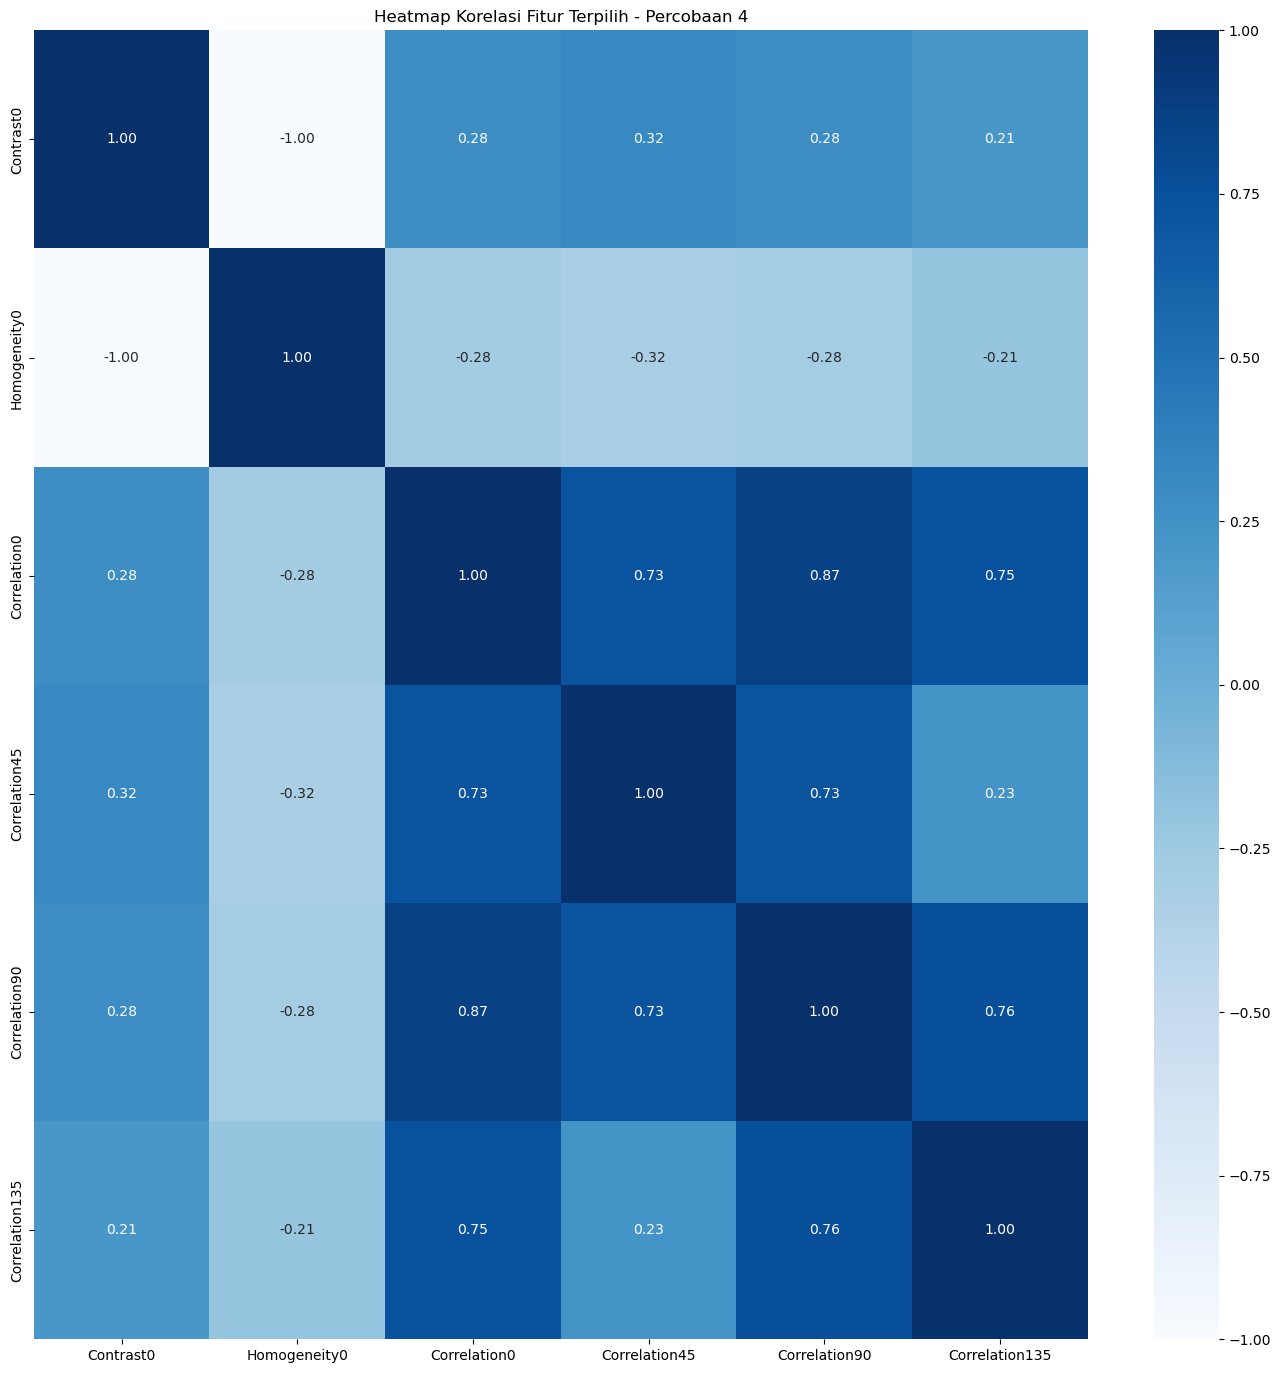

In [271]:
correlation_matrix = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()

ambang_korelasi = 0.95
columns_mask = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i, j] >= ambang_korelasi:
            if columns_mask[j]:
                columns_mask[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns_mask]
x_new  = hasilEkstrak[select]
y      = hasilEkstrak['Label']

print(f'Fitur sebelum seleksi : {hasilEkstrak.shape[1] - 2}')
print(f'Fitur setelah seleksi : {x_new.shape[1]}')
print(f'Fitur terpilih        : {list(select)}')

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Heatmap Korelasi Fitur Terpilih - Percobaan 4')
plt.show()


## **PEMBAGIAN DATA**

In [272]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape :', y_test.shape)

X_train shape: (128, 6)
X_test shape : (32, 6)
y_train shape: (128,)
y_test shape : (32,)


*Cell code* di atas digunakan untuk membagi dataset fitur ke dalam set data latih dan data uji menggunakan fungsi `train_test_split()` dari *library* **scikit-learn**. Pembagian dilakukan dengan proporsi **80% data latih** dan **20% data uji** menggunakan parameter `test_size=0.2`. Parameter `random_state=42` digunakan untuk memastikan hasil pembagian bersifat reproducible (selalu menghasilkan kombinasi data yang sama setiap kali dijalankan). Dimensi keempat variabel hasil pembagian (`X_train`, `X_test`, `y_train`, `y_test`) kemudian dicetak sebagai konfirmasi.

## **NORMALISASI FITUR**

Menggunakan **Z-score Standardization**. Mean dan standar deviasi dihitung dari data latih, lalu diterapkan ke keduanya agar tidak terjadi *data leakage*.

In [273]:
train_mean = X_train.mean()
train_std  = X_train.std()

X_train = (X_train - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std

print('Normalisasi selesai (Z-score / Standardization).')


Normalisasi selesai (Z-score / Standardization).


*Cell code* di atas mengimplementasikan teknik normalisasi **Z-score Standardization** (*Standarisasi*) terhadap matriks fitur. Mean (`train_mean`) dan standar deviasi (`train_std`) dihitung hanya dari `X_train` agar parameter normalisasi sepenuhnya berasal dari data latih. Kedua parameter ini kemudian diterapkan pada `X_train` maupun `X_test` menggunakan rumus $z = (x - \mu) / \sigma$. Pendekatan ini penting untuk mencegah *data leakage*, yaitu kondisi di mana informasi dari data uji secara tidak sengaja memengaruhi proses pelatihan model, yang dapat menghasilkan estimasi performa yang terlalu optimistis.

## **PEMODELAN**


### **MENDEFINISIKAN MODEL DAN FUNGSI LAPORAN**

In [274]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print('Confusion Matrix:')
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', round(accuracy_score(y_true, y_pred), 4))

rf4  = RandomForestClassifier(n_estimators=5, random_state=42)
svm4 = SVC(kernel='rbf', random_state=42)
knn4 = KNeighborsClassifier(n_neighbors=5)

*Cell code* di atas digunakan untuk mendefinisikan fungsi `generateClassificationReport()` sebagai pembungkus ringkas untuk mencetak laporan evaluasi model, serta menginisialisasi ketiga model klasifikasi yang akan dibandingkan. Fungsi laporan mencetak *classification report* lengkap (precision, recall, F1-score per kelas), *confusion matrix*, dan akurasi keseluruhan. Model **Random Forest** (`rf4`) dikonfigurasi dengan 5 pohon keputusan (`n_estimators=5`) dan `random_state=42`. Model **SVM** (`svm4`) menggunakan *kernel* RBF (*Radial Basis Function*) yang cocok untuk data berdimensi tinggi dan tidak linier. Model **KNN** (`knn4`) menggunakan 5 tetangga terdekat (`n_neighbors=5`) sebagai dasar keputusan klasifikasinya.

### **RANDOM FOREST**

In [275]:
rf4.fit(X_train, y_train)

print('====== Random Forest ======')
print('\n--- Training Set ---')
generateClassificationReport(y_train, rf4.predict(X_train))
print('\n--- Testing Set ---')
generateClassificationReport(y_test, rf4.predict(X_test))


====== Random Forest ======

--- Training Set ---
              precision    recall  f1-score   support

    diseased       0.95      0.98      0.97        64
     healthy       0.98      0.95      0.97        64

    accuracy                           0.97       128
   macro avg       0.97      0.97      0.97       128
weighted avg       0.97      0.97      0.97       128

Confusion Matrix:
[[63  1]
 [ 3 61]]
Accuracy: 0.9688

--- Testing Set ---
              precision    recall  f1-score   support

    diseased       0.88      0.88      0.88        16
     healthy       0.88      0.88      0.88        16

    accuracy                           0.88        32
   macro avg       0.88      0.88      0.88        32
weighted avg       0.88      0.88      0.88        32

Confusion Matrix:
[[14  2]
 [ 2 14]]
Accuracy: 0.875


*Cell code* di atas digunakan untuk melatih model *Random Forest* (`rf4`) menggunakan data latih `X_train` dan `y_train` melalui metode `.fit()`. Setelah pelatihan selesai, performa model dievaluasi pada dua set data: **data latih** (untuk melihat seberapa baik model mempelajari pola) dan **data uji** (untuk mengukur kemampuan generalisasi). Evaluasi dilakukan dengan memanggil fungsi `generateClassificationReport()` yang mencetak *classification report* dan akurasi untuk masing-masing set secara terpisah.

### **SVM (SUPPORT VECTOR MACHINE)**

In [276]:
svm4.fit(X_train, y_train)

print('====== SVM (RBF Kernel) ======')
print('\n--- Training Set ---')
generateClassificationReport(y_train, svm4.predict(X_train))
print('\n--- Testing Set ---')
generateClassificationReport(y_test, svm4.predict(X_test))


====== SVM (RBF Kernel) ======

--- Training Set ---
              precision    recall  f1-score   support

    diseased       0.91      0.78      0.84        64
     healthy       0.81      0.92      0.86        64

    accuracy                           0.85       128
   macro avg       0.86      0.85      0.85       128
weighted avg       0.86      0.85      0.85       128

Confusion Matrix:
[[50 14]
 [ 5 59]]
Accuracy: 0.8516

--- Testing Set ---
              precision    recall  f1-score   support

    diseased       0.92      0.75      0.83        16
     healthy       0.79      0.94      0.86        16

    accuracy                           0.84        32
   macro avg       0.86      0.84      0.84        32
weighted avg       0.86      0.84      0.84        32

Confusion Matrix:
[[12  4]
 [ 1 15]]
Accuracy: 0.8438


*Cell code* di atas digunakan untuk melatih model **SVM** dengan *kernel* RBF (`svm4`) pada data latih yang sama. SVM bekerja dengan mencari *hyperplane* pemisah optimal di ruang fitur berdimensi tinggi, sedangkan *kernel* RBF memungkinkan pemisahan data yang tidak dapat dipisahkan secara linier. Evaluasi performa dilakukan dengan cara yang sama seperti *Random Forest*, yaitu pada data latih dan data uji secara terpisah menggunakan fungsi `generateClassificationReport()`.

### **KNN (K-NEAREST NEIGHBORS)**

In [277]:
knn4.fit(X_train, y_train)

print('====== KNN (k=5) ======')
print('\n--- Training Set ---')
generateClassificationReport(y_train, knn4.predict(X_train))
print('\n--- Testing Set ---')
generateClassificationReport(y_test, knn4.predict(X_test))


====== KNN (k=5) ======

--- Training Set ---
              precision    recall  f1-score   support

    diseased       0.87      0.73      0.80        64
     healthy       0.77      0.89      0.83        64

    accuracy                           0.81       128
   macro avg       0.82      0.81      0.81       128
weighted avg       0.82      0.81      0.81       128

Confusion Matrix:
[[47 17]
 [ 7 57]]
Accuracy: 0.8125

--- Testing Set ---
              precision    recall  f1-score   support

    diseased       0.92      0.69      0.79        16
     healthy       0.75      0.94      0.83        16

    accuracy                           0.81        32
   macro avg       0.83      0.81      0.81        32
weighted avg       0.83      0.81      0.81        32

Confusion Matrix:
[[11  5]
 [ 1 15]]
Accuracy: 0.8125


*Cell code* di atas digunakan untuk melatih model **KNN** (`knn4`) dengan jumlah tetangga `k=5` pada data latih. KNN adalah algoritma berbasis instansi (*instance-based*) yang tidak membangun model eksplisit, melainkan mengklasifikasikan data baru berdasarkan mayoritas label dari 5 data latih yang paling dekat jaraknya. Evaluasi performa dilakukan dengan cara yang sama seperti dua model sebelumnya.

## **EVALUASI**


### **CONFUSION MATRIX**

*Cell code* di bawah mendefinisikan fungsi `plot_confusion_matrix()` dan langsung menggunakannya untuk memvisualisasikan *confusion matrix* dari ketiga model pada data uji. *Confusion matrix* menampilkan jumlah prediksi yang benar (*True Positive*, *True Negative*) dan prediksi yang salah (*False Positive*, *False Negative*) dalam bentuk matriks 2×2. Fungsi `ConfusionMatrixDisplay` dari **scikit-learn** digunakan untuk menghasilkan visualisasi berwarnaformat *heatmap* menggunakan palet warna `plt.cm.Blues`, sehingga intensitas warna yang lebih pekat merepresentasikan jumlah sampel yang lebih besar.

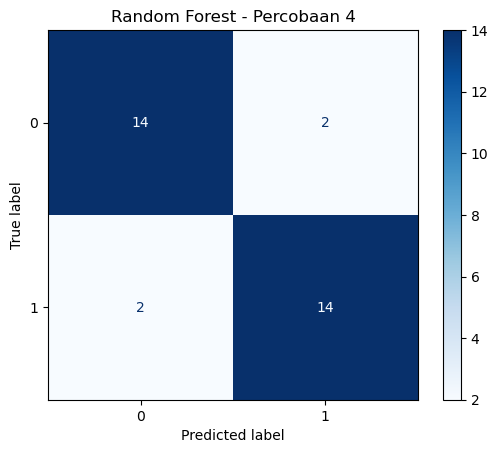

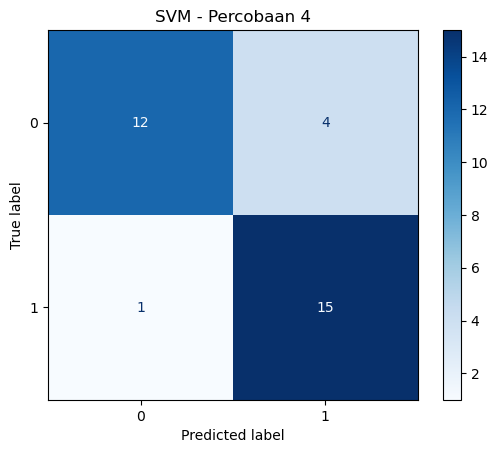

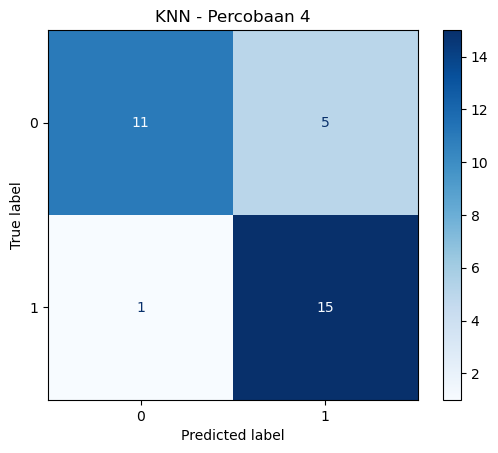

In [278]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, rf4.predict(X_test),  'Random Forest - Percobaan 4')
plot_confusion_matrix(y_test, svm4.predict(X_test), 'SVM - Percobaan 4')
plot_confusion_matrix(y_test, knn4.predict(X_test), 'KNN - Percobaan 4')


### **TABEL PERBANDINGAN MODEL**

In [279]:
def display_model_comparison(y_true, rf_pred, svm_pred, knn_pred, model_names=['Random Forest', 'SVM', 'KNN']):
    metrics = {
        'Accuracy': accuracy_score,
        'Precision': precision_score,
        'Recall': recall_score,
        'F1-Score': f1_score
    }
    comparison_data = {}
    for name, pred in zip(model_names, [rf_pred, svm_pred, knn_pred]):
        comparison_data[name] = {}
        for metric_name, metric_func in metrics.items():
            if metric_name in ['Precision', 'Recall', 'F1-Score']:
                scores = metric_func(y_true, pred, average='weighted')
                comparison_data[name][metric_name] = scores
            else:
                comparison_data[name][metric_name] = metric_func(y_true, pred)
    df_comparison = pd.DataFrame(comparison_data).T
    print("\nTABEL PERBANDINGAN MODEL - PERCOBAAN 4")
    display(df_comparison)
    return df_comparison

rf_pred = rf4.predict(X_test)
svm_pred = svm4.predict(X_test)
knn_pred = knn4.predict(X_test)
df_comparison = display_model_comparison(y_test, rf_pred, svm_pred, knn_pred)


TABEL PERBANDINGAN MODEL - PERCOBAAN 4


,Accuracy,Precision,Recall,F1-Score
Random Forest,0.87500,0.875000,0.87500,0.875000
SVM,0.84375,0.856275,0.84375,0.842365
KNN,0.81250,0.833333,0.81250,0.809524


*Cell code* di atas mendefinisikan fungsi `display_model_comparison()` yang merangkum empat metrik evaluasi utama dari ketiga model ke dalam satu tabel *DataFrame* yang terstruktur. Metrik yang dihitung meliputi **Accuracy** (proporsi prediksi benar keseluruhan), **Precision** (ketepatan prediksi positif), **Recall** (kelengkapan dalam mendeteksi kelas positif), dan **F1-Score** (rata-rata harmonik Precision dan Recall). Untuk metrik selain Accuracy, digunakan parameter `average='weighted'` agar bobot tiap kelas proporsional terhadap jumlah sampelnya. Hasil akhirnya ditampilkan sebagai tabel perbandingan model yang dapat di-*screenshot* untuk keperluan presentasi.

### **RINGKASAN AKURASI**

In [280]:
models = {'Random Forest': rf4, 'SVM': svm4, 'KNN': knn4}

Width = 56
print('=' * Width)
print(f'|{"RINGKASAN AKURASI - PERCOBAAN 4":<{Width-2}}|')
print(f'|{"Preprocessing: Resize + Grayscale":<{Width-2}}|')
print(f'|{"             + Histogram Equalization + Median":<{Width-2}}|')
print(f'|{"             + Sobel + Threshold":<{Width-2}}|')
print(f'|{"             + Opening + Closing":<{Width-2}}|')
print('=' * Width)
print(f'|{"Model":^21}|{"Train Accuracy":^16}|{"Test Accuracy":^15}|')
print(f'|{"-" * (Width-2)}|')
for nama, model in models.items():
    acc_train = accuracy_score(y_train, model.predict(X_train))
    acc_test  = accuracy_score(y_test,  model.predict(X_test))
    print(f'| {nama:<19} | {acc_train:>14.4f} | {acc_test:>13.4f} |')
print('=' * Width)

|RINGKASAN AKURASI - PERCOBAAN 4                       |
|Preprocessing: Resize + Grayscale                     |
|             + Histogram Equalization + Median        |
|             + Sobel + Threshold                      |
|             + Opening + Closing                      |
|        Model        | Train Accuracy | Test Accuracy |
|------------------------------------------------------|
| Random Forest       |         0.9688 |        0.8750 |
| SVM                 |         0.8516 |        0.8438 |
| KNN                 |         0.8125 |        0.8125 |


*Cell code* di atas digunakan untuk mencetak ringkasan akurasi ketiga model dalam format tabel teks yang terstruktur. Berbeda dengan tabel perbandingan sebelumnya yang mencakup empat metrik, bagian ini secara khusus menampilkan perbandingan akurasi antara **data latih** dan **data uji** untuk setiap model. Perbandingan ini berguna untuk mendeteksi potensi *overfitting*, yaitu kondisi di mana model terlalu baik pada data latih tetapi kurang mampu melakukan generalisasi pada data uji.